In [ ]:
import numpy as np
import pickle

with open("2d_eig_rect_mt_mean.pkl", "rb") as f:   # 'rb' = read binary
    flux = pickle.load(f)

with open("2d_eig_rect_mt_stdev.pkl", "rb") as f:   # 'rb' = read binary
    std = pickle.load(f)

flux = np.prod(flux.shape) / np.sum(flux) * flux
print(np.min(std))
print(np.max(std))
p = np.sum(np.abs(std) > 0.02) / np.prod(std.shape) * 100.0
print(p)

0.003545357401924517
0.15447464550795018
13.755208333333332


In [ ]:
import tntorch as tn

with open("tt_2d_eig_rect_mt_mean.pkl", "rb") as f:   # 'rb' = read binary
    tt = pickle.load(f)

with open("tt_2d_eig_rect_mt_stdev.pkl", "rb") as f:   # 'rb' = read binary
    tt_std = pickle.load(f)

print(type(tt))
flux_tt = tt.torch().numpy()
flux_tt = np.prod(flux_tt.shape) / np.sum(flux_tt) * flux_tt
err = (flux-flux_tt) / flux * 100.0
rmsre = np.linalg.norm(err) / np.prod(flux_tt.shape)
print(np.max(err), np.min(err))
print(rmsre, " %")
E_rel = np.linalg.norm(flux-flux_tt) / np.linalg.norm(flux) * 100.0
print(E_rel, " %")

# percentage meshes with error larger than 2%
p = np.sum(np.abs(err) > 5.0) / np.prod(flux_tt.shape) * 100.0
print(p)

std_tt = tt_std.torch().numpy()
print(np.min(std_tt))


<class 'tntorch.tensor.Tensor'>
52.402973773585245 -81.49643884652271
0.020830601115939925  %
0.9267943714179935  %
6.977430555555555
-0.0015047479717154146


153.29046940147836 153.4490750864514


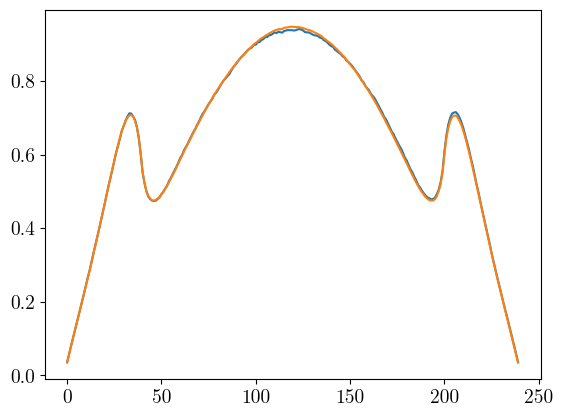

In [ ]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Latin Modern Math"
plt.rcParams["mathtext.default"] = "regular"
plt.rcParams.update({'font.size': 14})

flux_1d_tt = np.average(flux_tt[1,:,:,0], axis=1)
flux_1d = np.average(flux[1,:,:,0], axis=1)
err_1d = (flux_1d - flux_1d_tt) / flux_1d * 100
print(np.sum(flux_1d), np.sum(flux_1d_tt))
# fig, (ax1) = plt.subplots(1, constrained_layout=True)
plt.plot(flux_1d_tt)
plt.plot(flux_1d)
# plt.show()
# plt.savefig('exp.jpg', dpi=1200)


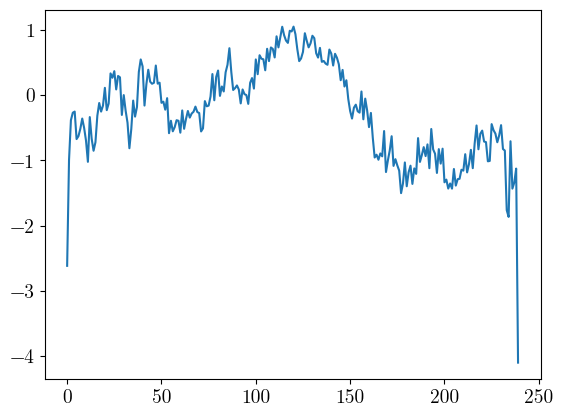

In [ ]:
err_1d = (flux_1d - flux_1d_tt) / flux_1d * 100
plt.plot(err_1d)

In [ ]:
import pyvista as pv

ng, nx, ny, nz = np.shape(flux)
xmax = 120.0
ymax = 60.0
zmax = 1.0

x = np.linspace(0.0, xmax, nx)
y = np.linspace(0.0, ymax, ny)
z = np.linspace(0.0, zmax, nz)

X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

# Create a structured grid
grid = pv.StructuredGrid(X, Y, Z)
data = flux[1,:,:,0]
grid["my_scalar"] = data.ravel(order="F")
grid.save("flux.vtk")



StructuredGrid (0x7a02ec138220)
  N Cells:      28441
  N Points:     28800
  X Bounds:     0.000e+00, 1.200e+02
  Y Bounds:     0.000e+00, 6.000e+01
  Z Bounds:     0.000e+00, 0.000e+00
  Dimensions:   240, 120, 1
  N Arrays:     1


/home/imronuke/miniconda3/envs/mcpy_env/lib/python3.13/site-packages/pyvista/jupyter/notebook.py:56: UserWarning: Failed to use notebook backend: 

cannot import name 'vtk' from 'trame.widgets' (/home/imronuke/miniconda3/envs/mcpy_env/lib/python3.13/site-packages/trame/widgets/__init__.py)

Falling back to a static output.
  warnings.warn(


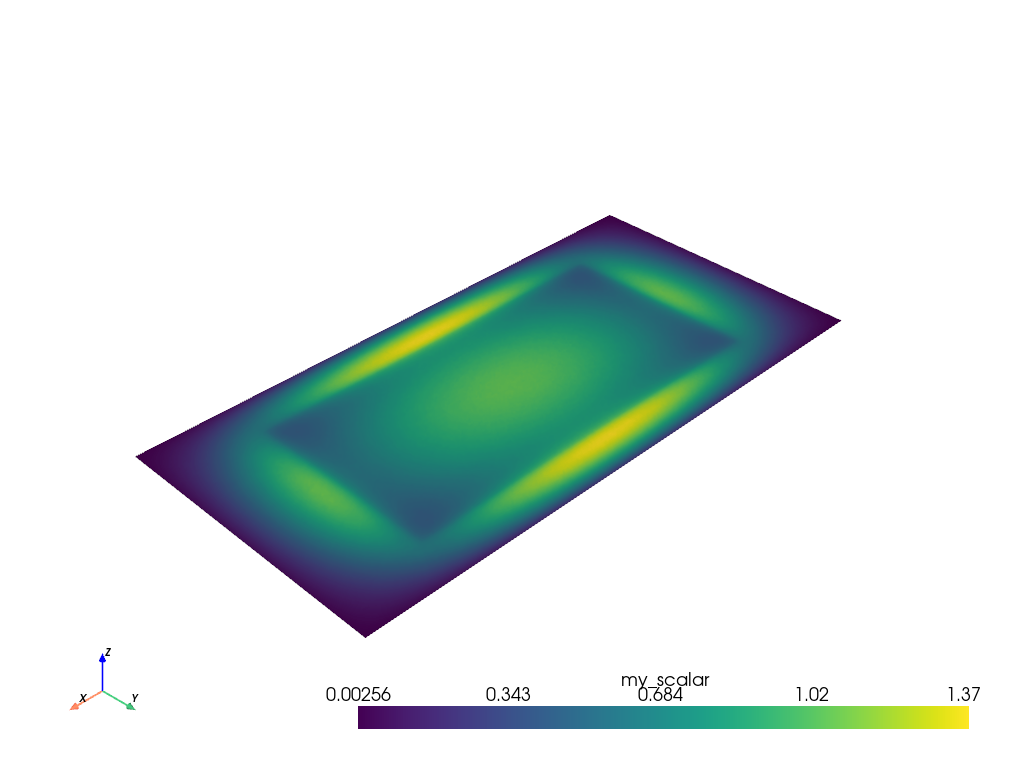

In [ ]:
mesh = pv.read("flux.vtk")
print(mesh)
mesh.plot()